In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib.pyplot as plt
import wandb
import pprint

In [2]:
wandb.login()

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: me21b145 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
sweep_config = {'method': 'random'}

metric = {
    'name': 'reward',
    'goal': 'maximize'   
    }
sweep_config['metric'] = metric

parameters = {
    'learning_rate': {'values': [0.01, 0.05, 0.001]},
    'batch_size': {'values': [64, 128]},
    'episodes': {'values': [250, 500, 750, 1000]},
    'discount_factor':{'value':0.99},
    'epsilon': {'values':[0.1, 0.2, 0.3]},
    'epsilon_decay': {'values':[0.9995, 0.999, 0.998]},
    }
sweep_config['parameters'] = parameters

pprint.pprint(sweep_config)
sweep_id = wandb.sweep(sweep_config, project="RL_PA2_CartPole_DQN")

{'method': 'random',
 'metric': {'goal': 'maximize', 'name': 'reward'},
 'parameters': {'batch_size': {'values': [64, 128]},
                'discount_factor': {'value': 0.99},
                'episodes': {'values': [250, 500, 750, 1000]},
                'epsilon': {'values': [0.1, 0.2, 0.3]},
                'epsilon_decay': {'values': [0.9995, 0.999, 0.998]},
                'learning_rate': {'values': [0.01, 0.05, 0.001]}}}
Create sweep with ID: y8jmnq0t
Sweep URL: https://wandb.ai/me21b145/RL_PA2_CartPole_DQN/sweeps/y8jmnq0t


In [4]:
GAMMA = 0.99
LR = 1e-3
BATCH_SIZE = 64
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
MEMORY_SIZE = 10000
TARGET_UPDATE_FREQ = 10
NUM_EPISODES = 500

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
class DuelingDQN(nn.Module):
    def __init__(self, state_dim, action_dim, type=1):
        super(DuelingDQN, self).__init__()
        self.type = type
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU()
        )
        self.value_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.advantage_stream = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        x = self.shared(x)
        value = self.value_stream(x)
        advantage = self.advantage_stream(x)
        if self.type == 1:
            advantage_mean = advantage.mean(dim=1, keepdim=True)
            q = value + (advantage - advantage_mean)
        else:  # Type-2
            advantage_max = advantage.max(dim=1, keepdim=True)[0]
            q = value + (advantage - advantage_max)
        return q

In [7]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return map(np.array, zip(*batch))

    def __len__(self):
        return len(self.buffer)

In [8]:
def select_action(state, policy_net, epsilon, action_dim):
    if random.random() < epsilon:
        return random.randint(0, action_dim - 1)
    with torch.no_grad():
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        return policy_net(state).argmax().item()

In [9]:
def compute_returns(rewards, discount=0.99):
    G = 0
    returns = []
    for r in reversed(rewards):
        G = r + discount * G
        returns.insert(0, G)
    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    return returns

In [15]:
def train_dueling_dqn(env, lr, epsilon, epsilon_decay, episodes, discount, batch_size, device, type=1, is_wandb=False):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy_net = DuelingDQN(state_dim, action_dim, type).to(device)
    target_net = DuelingDQN(state_dim, action_dim, type).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr)
    memory = ReplayBuffer(MEMORY_SIZE)

    episode_rewards = []
    return_per_episode = []

    for episode in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(500):
            action = select_action(state, policy_net, epsilon, action_dim)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            memory.push((state, action, reward, next_state, done))
            state = next_state
            total_reward += reward

            if len(memory) >= batch_size:
                states, actions, rewards, next_states, dones = memory.sample(batch_size)
                states = torch.tensor(states, dtype=torch.float32).to(device)
                actions = torch.tensor(actions, dtype=torch.int64).unsqueeze(1).to(device)
                rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
                next_states = torch.tensor(next_states, dtype=torch.float32).to(device)
                dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)

                q_values = policy_net(states).gather(1, actions)
                next_q_values = target_net(next_states).max(1)[0].unsqueeze(1)
                targets = rewards + discount * next_q_values * (1 - dones)

                loss = nn.MSELoss()(q_values, targets)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(EPSILON_END, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

        if episode == 0:
            return_per_episode.append(total_reward)
        else:
            return_per_episode.append(episode_rewards[-1]*discount + total_reward)

        if is_wandb:
            wandb.log({"episode": episode, "return": total_reward})

        if episode % TARGET_UPDATE_FREQ == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if episode % 10 == 0:
            print(f"Episode {episode}, Reward: {total_reward:.2f}, Epsilon: {epsilon:.3f}")

    env.close()
    returns = compute_returns(episode_rewards, discount)
    return episode_rewards, return_per_episode, returns

In [11]:
def DQN():
    env = gym.make("CartPole-v1")
    config = None
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    with wandb.init(config=config):
        lr = wandb.config.learning_rate
        discount = wandb.config.discount_factor
        episodes = wandb.config.episodes
        epsilon = wandb.config.epsilon
        epsilon_decay = wandb.config.epsilon_decay
        batch_size = wandb.config.batch_size
        rewards_type1, returns_type1, returns1 = train_dueling_dqn(env, lr, epsilon, epsilon_decay, episodes, discount, batch_size, device, type=1, is_wandb=True)
        rewards_type2, returns_type2, returns2 = train_dueling_dqn(env, lr, epsilon, epsilon_decay, episodes, discount, batch_size, device, type=2, is_wandb=True)

        plt.figure(figsize=(12, 5))
        plt.plot(rewards_type1, 'r', label="Reward with Type 1 update")
        plt.plot(rewards_type2, 'g', label="Reward with Type 2 update")
        plt.xlabel("Episodes")
        plt.ylabel("Rewards")
        plt.title("Rewards per episode (Type 1 vs Type 2)")
        plt.legend()
        plt.tight_layout()
        #plt.savefig(f'SARSA_Mountaincar_{wandb.config.discretization_bins}_{wandb.config.learning_rate}_{wandb.config.episodes}.png')

        wandb.log({'Learning Rate': wandb.config.learning_rate, 'Episodes': wandb.config.episodes, 'Rewards per episode': wandb.Image(plt)})
        plt.close()

        env.close()

In [12]:
wandb.agent(sweep_id, DQN, count=1)

wandb: Agent Starting Run: csvx1rh8 with config:
wandb: 	batch_size: 64
wandb: 	discount_factor: 0.99
wandb: 	episodes: 250
wandb: 	epsilon: 0.1
wandb: 	epsilon_decay: 0.999
wandb: 	learning_rate: 0.05
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Episode 0, Reward: 9.00, Epsilon: 0.100
Episode 10, Reward: 20.00, Epsilon: 0.099
Episode 20, Reward: 10.00, Epsilon: 0.098
Episode 30, Reward: 18.00, Epsilon: 0.097
Episode 40, Reward: 16.00, Epsilon: 0.096
Episode 50, Reward: 8.00, Epsilon: 0.095
Episode 60, Reward: 16.00, Epsilon: 0.094
Episode 70, Reward: 18.00, Epsilon: 0.093
Episode 80, Reward: 24.00, Epsilon: 0.092
Episode 90, Reward: 13.00, Epsilon: 0.091
Episode 100, Reward: 11.00, Epsilon: 0.090
Episode 110, Reward: 24.00, Epsilon: 0.089
Episode 120, Reward: 11.00, Epsilon: 0.089
Episode 130, Reward: 17.00, Epsilon: 0.088
Episode 140, Reward: 25.00, Epsilon: 0.087
Episode 150, Reward: 25.00, Epsilon: 0.086
Episode 160, Reward: 20.00, Epsilon: 0.085
Episode 170, Reward: 14.00, Epsilon: 0.084
Episode 180, Reward: 20.00, Epsilon: 0.083
Episode 190, Reward: 10.00, Epsilon: 0.083
Episode 200, Reward: 10.00, Epsilon: 0.082
Episode 210, Reward: 9.00, Epsilon: 0.081
Episode 220, Reward: 35.00, Epsilon: 0.080
Episode 230, Reward: 11.0

Episodes,▁
Learning Rate,▁
episode,▁▂▂▃▃▃▄▄▄▄▅▅▅▆▆▇▇███▁▁▁▂▂▃▄▄▄▄▅▅▅▆▆▆▇▇▇█
return,▃▂▄▂▁▁▃▁▄▂▆▅█▁▁▁▁▃▂▃▂▁▁▂▁▁▃▁▁▂▁▁▅▂▅▂▂▄▃▃
Episodes,250
Learning Rate,0.05
episode,249
return,16


In [12]:
def mean_and_variance(x):
    sum_mean = 0
    mean = []
    variance = []
    for i in range(len(x)):
        sum_mean += x[i]
        mean.append(sum_mean/(i+1))
        sum_variance = 0
        for j in range(0,i+1):
            sum_variance += (x[j] - mean[i])**2
        variance.append(sum_variance/(i+1))

    return mean, variance

Episode 0, Reward: 11.00, Epsilon: 0.100
Episode 10, Reward: 9.00, Epsilon: 0.099
Episode 20, Reward: 13.00, Epsilon: 0.099
Episode 30, Reward: 17.00, Epsilon: 0.098
Episode 40, Reward: 24.00, Epsilon: 0.098
Episode 50, Reward: 9.00, Epsilon: 0.097
Episode 60, Reward: 18.00, Epsilon: 0.097
Episode 70, Reward: 20.00, Epsilon: 0.097
Episode 80, Reward: 120.00, Epsilon: 0.096
Episode 90, Reward: 130.00, Epsilon: 0.096
Episode 100, Reward: 98.00, Epsilon: 0.095
Episode 110, Reward: 363.00, Epsilon: 0.095
Episode 120, Reward: 216.00, Epsilon: 0.094
Episode 130, Reward: 183.00, Epsilon: 0.094
Episode 140, Reward: 88.00, Epsilon: 0.093
Episode 150, Reward: 430.00, Epsilon: 0.093
Episode 160, Reward: 74.00, Epsilon: 0.092
Episode 170, Reward: 116.00, Epsilon: 0.092
Episode 180, Reward: 63.00, Epsilon: 0.091
Episode 190, Reward: 160.00, Epsilon: 0.091
Episode 200, Reward: 385.00, Epsilon: 0.090
Episode 210, Reward: 44.00, Epsilon: 0.090
Episode 220, Reward: 25.00, Epsilon: 0.090
Episode 230, Re

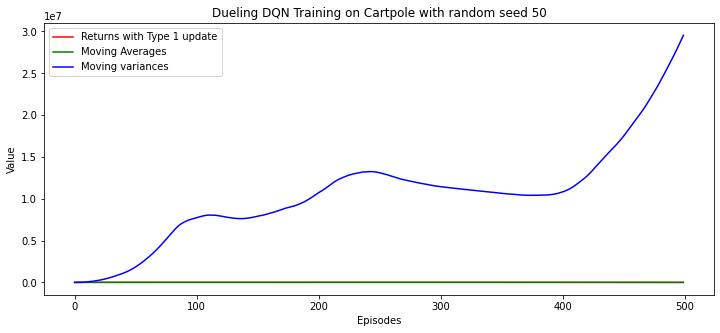

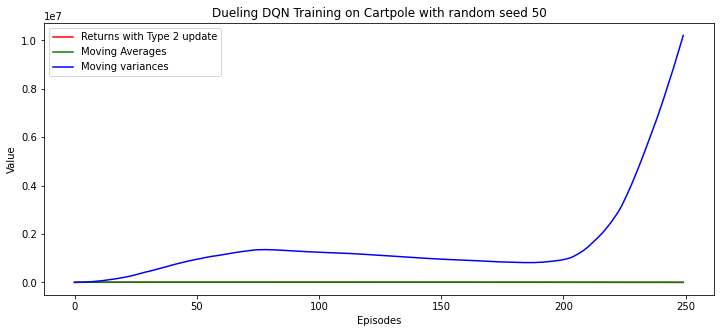

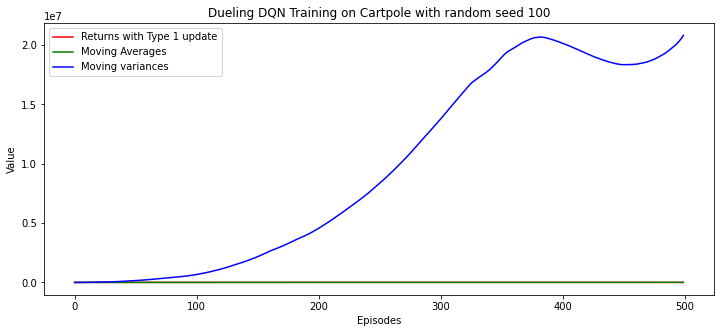

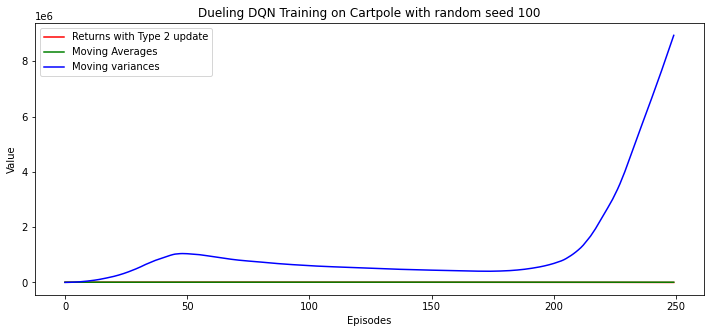

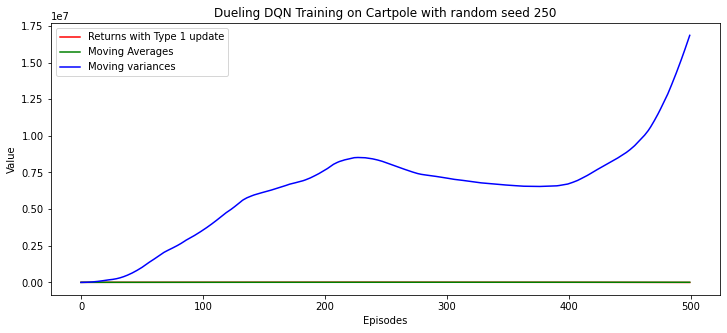

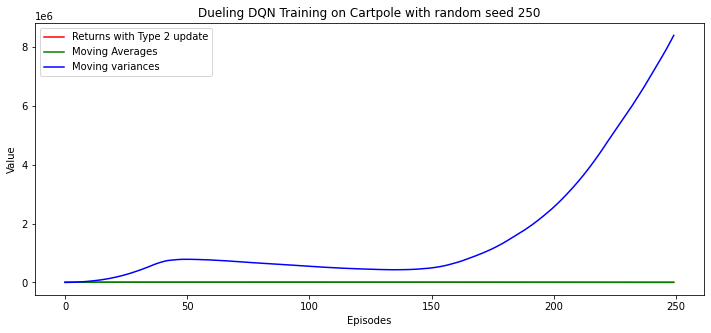

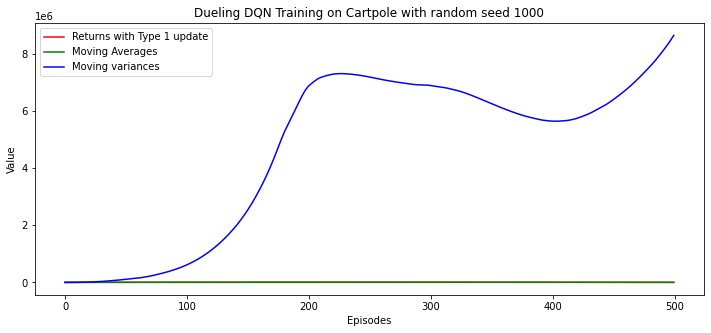

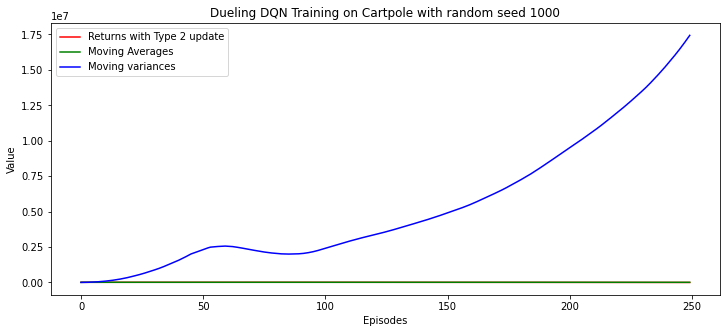

In [ ]:
seeds = [10, 50, 100, 250, 1000]

env = gym.make("CartPole-v1")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for seed in seeds:
    np.random.seed(seed)
    random.seed(seed)

    lr = 0.01
    epsilon = 0.1
    epsilon_decay = 0.9995
    episodes = 500
    discount = 0.99
    batch_size = 64
    rewards_type1, returns_type1, returns1 = train_dueling_dqn(env, lr, epsilon, epsilon_decay, episodes, discount, batch_size, device, type=1, is_wandb=False)

    mean_returns_type1, var_returns_type1 = mean_and_variance(returns1)

    lr = 0.001
    epsilon = 0.3
    epsilon_decay = 0.998
    episodes = 250
    discount = 0.99
    batch_size = 64
    rewards_type2, returns_type2, returns2 = train_dueling_dqn(env, lr, epsilon, epsilon_decay, episodes, discount, batch_size, device, type=1, is_wandb=False)

    mean_returns_type2, var_returns_type2 = mean_and_variance(returns2)

    plt.figure(figsize=(12, 5))
    plt.plot(returns1, 'r', label="Returns with Type 1 update")
    plt.plot(mean_returns_type1, 'g', label="Moving Averages")
    plt.plot(var_returns_type1, 'b', label="Moving variances")
    plt.xlabel("Episodes")
    plt.ylabel("Value")
    plt.title(f"Dueling DQN Training on Cartpole with random seed {seed}")
    plt.legend()

    plt.figure(figsize=(12, 5))
    plt.plot(returns2, 'r', label="Returns with Type 2 update")
    plt.plot(mean_returns_type2, 'g', label="Moving Averages")
    plt.plot(var_returns_type2, 'b', label="Moving variances")
    plt.xlabel("Episodes")
    plt.ylabel("Value")
    plt.title(f"Dueling DQN Training on Cartpole with random seed {seed}")
    plt.legend()
    
    print(f"Seed {seed} Done")